# Air Brakes — Baseline (No Controller)

Identical Calisto rocket to `airbrakes0–3` but with **no air-brakes aerosurface and no controller** attached. The resulting apogee is the reference altitude the controlled runs are trying to reduce.


In [1]:
!python -m pip install -e ../../.

/bin/bash: line 1: python: command not found


## Setting Up The Simulation

First, lets define everything we need for the simulation up to the rocket:

In [2]:
from rocketpy import Environment, SolidMotor, Rocket, Flight

env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)

Pro75M1670 = SolidMotor(
    thrust_source="../../data/motors/cesaroni/Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="../../data/rockets/calisto/powerOffDragCurve.csv",
    power_on_drag="../../data/rockets/calisto/powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = calisto.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.618,
    angular_position=45,
)

calisto.add_motor(Pro75M1670, position=-1.255)

nose_cone = calisto.add_nose(
    length=0.55829, kind="vonKarman", position=1.278
)

fin_set = calisto.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
    airfoil=("../../data/airfoils/NACA0012-radians.txt","radians"),
)

tail = calisto.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

## Simulating a Flight

No controller is attached, so `time_overshoot=False` is no longer required. We still set `terminate_on_apogee=True` to halt at apogee.


In [3]:
test_flight = Flight(
    rocket=calisto,
    environment=env,
    rail_length=5.2,
    inclination=85,
    heading=0,
    terminate_on_apogee=True,
)


## Analyzing the Results

Without a controller there are no `observed_variables` to plot. We summarise the flight by plotting altitude AGL and vertical velocity, and we print the apogee so it can be compared against the controlled runs in `airbrakes0–3`.


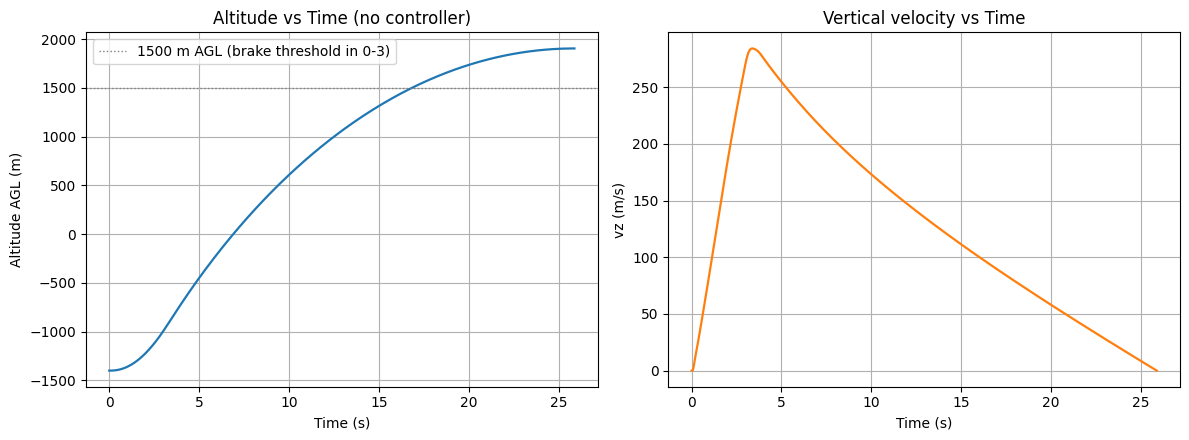

In [4]:
import matplotlib.pyplot as plt
import numpy as np

t_grid = np.linspace(0, test_flight.apogee_time, 400)
altitude_agl = np.array([test_flight.altitude(t) for t in t_grid]) - env.elevation
vz = np.array([test_flight.vz(t) for t in t_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(t_grid, altitude_agl, lw=1.6)
axes[0].axhline(1500, color="grey", ls=":", lw=1, label="1500 m AGL (brake threshold in 0-3)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Altitude AGL (m)")
axes[0].set_title("Altitude vs Time (no controller)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t_grid, vz, lw=1.6, color="C1")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("vz (m/s)")
axes[1].set_title("Vertical velocity vs Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Finally, the apogee number to compare against the other notebooks:


In [5]:
test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
print(f"\nBaseline apogee (AGL)        : {test_flight.altitude(test_flight.apogee_time):.2f} m")
print(f"Vertical velocity at apogee  : {test_flight.vz(test_flight.apogee_time):.4f} m/s")



Burn out State

Burn out time: 3.900 s
Altitude at burn out: 2057.369 m (ASL) | 657.369 m (AGL)
Rocket speed at burn out: 279.650 m/s
Freestream velocity at burn out: 279.650 m/s
Mach Number at burn out: 0.843
Kinetic energy at burn out: 6.351e+05 J

Apogee State

Apogee Time: 25.886 s
Apogee Altitude: 4705.474 m (ASL) | 3305.474 m (AGL)
Apogee Freestream Speed: 20.662 m/s
Apogee X position: -5.543 m
Apogee Y position: 588.779 m
Apogee latitude: 32.9955483°
Apogee longitude: -106.9750574°

Baseline apogee (AGL)        : 3305.47 m
Vertical velocity at apogee  : -0.0001 m/s
